# Evaluate Similarity per file embedding

In [44]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import util

## BGE-M3

In [ ]:
path_to_embeddings = './src/results/bge-m3/embeddings.pkl'
with open(path_to_embeddings, 'rb') as f:
    data_bge = pickle.load(f)
    print(f"Loaded {len(data_bge)} embeddings from {path_to_embeddings}")
embeddings_bge = data_bge['file_embedding']
print(f"Embeddings shape: {embeddings_bge.shape}")

Loaded 1085 embeddings from ./results/bge-m3/embeddings.pkl
Embeddings shape: (1085,)


In [46]:
# create similarity matrix
# similarity_matrix_bge = np.dot(embeddings_bge, embeddings_bge.T)
similarity_matrix_bge_model = util.cos_sim(embeddings_bge, embeddings_bge)
print(f"Similarity matrix shape: {similarity_matrix_bge_model.shape}")    



Similarity matrix shape: torch.Size([1085, 1085])


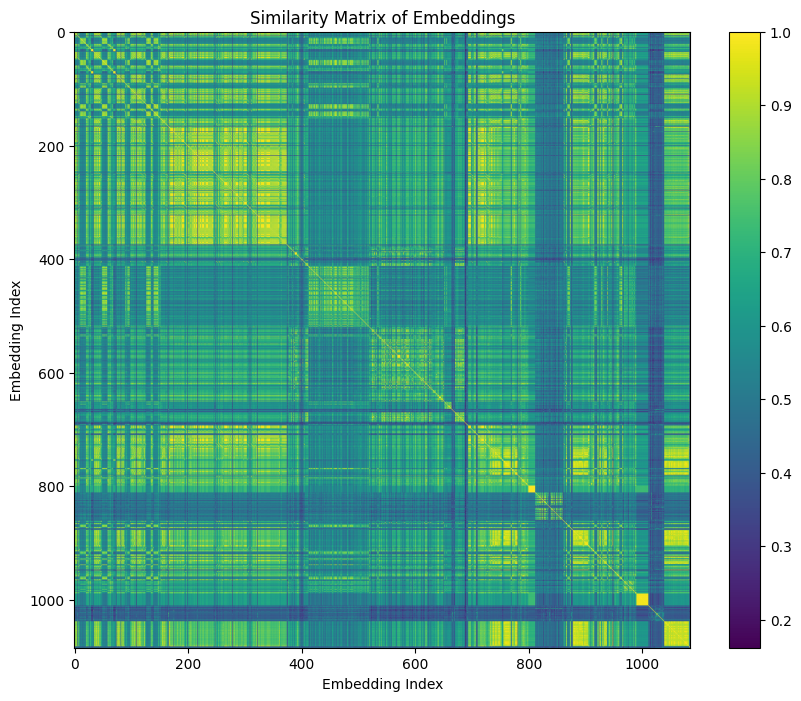

In [47]:
# plot similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix_bge_model, cmap='viridis')
plt.colorbar()
plt.title('Similarity Matrix of Embeddings')
plt.xlabel('Embedding Index')
plt.ylabel('Embedding Index')
plt.savefig('similarity_matrix_bge-m3.png')
plt.show()

Text(0, 0.5, 'Frequency')

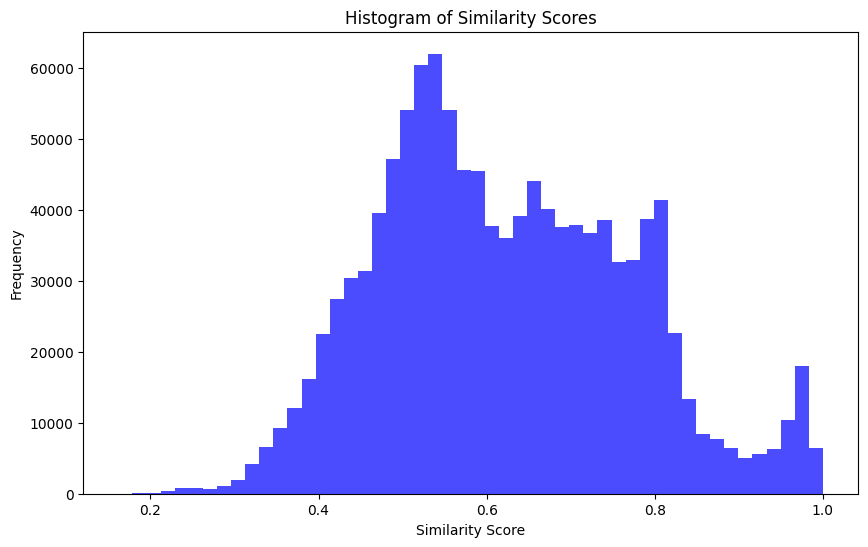

In [48]:
# make histogram of similarity scores
similarity_scores_bge = similarity_matrix_bge_model.flatten()
plt.figure(figsize=(10, 6))
plt.hist(similarity_scores_bge, bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Similarity Scores')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency') 

## E5-NL

In [49]:
path_to_embeddings_e5 = './results/embeddings.pkl'
with open(path_to_embeddings_e5, 'rb') as f:
    data_e5 = pickle.load(f)
    print(f"Loaded {len(data_e5)} embeddings from {path_to_embeddings_e5}")
embeddings_e5 = np.array(data_e5)
print(f"Embeddings shape: {embeddings_e5.shape}")

Loaded 1085 embeddings from ./results/embeddings.pkl
Embeddings shape: (1085, 6)


In [50]:
print(data_e5['file_embedding'])

0       [0.032714844, -0.06422119, -0.0501709, -0.0550...
1       [0.013061523, -0.03426514, -0.069970705, -0.06...
2       [0.007610784, -0.039223514, -0.05412314, -0.01...
3       [0.022954077, -0.07010174, -0.04650879, -0.052...
4       [0.016746521, -0.060668945, -0.05277109, -0.05...
                              ...                        
1080    [0.02808253, -0.07747396, -0.046571095, -0.015...
1081    [0.013983759, -0.04648107, -0.055148125, -0.01...
1082    [0.026611328, -0.02758789, -0.0107421875, -0.0...
1083    [0.026611328, -0.02758789, -0.0107421875, -0.0...
1084    [0.009521484, 0.067871094, -0.033935547, -0.06...
Name: file_embedding, Length: 1085, dtype: object


In [51]:
# similarity_matrix_e5 = np.dot(embeddings_e5, embeddings_e5.T)
embeddings_e5 = data_e5['file_embedding']
similarity_matrix_e5_model = util.cos_sim(embeddings_e5, embeddings_e5)
# print(f"Similarity matrix shape: {similarity_matrix_e5.shape}")    
print(f"Similarity matrix shape: {similarity_matrix_e5_model.shape}")

Similarity matrix shape: torch.Size([1085, 1085])


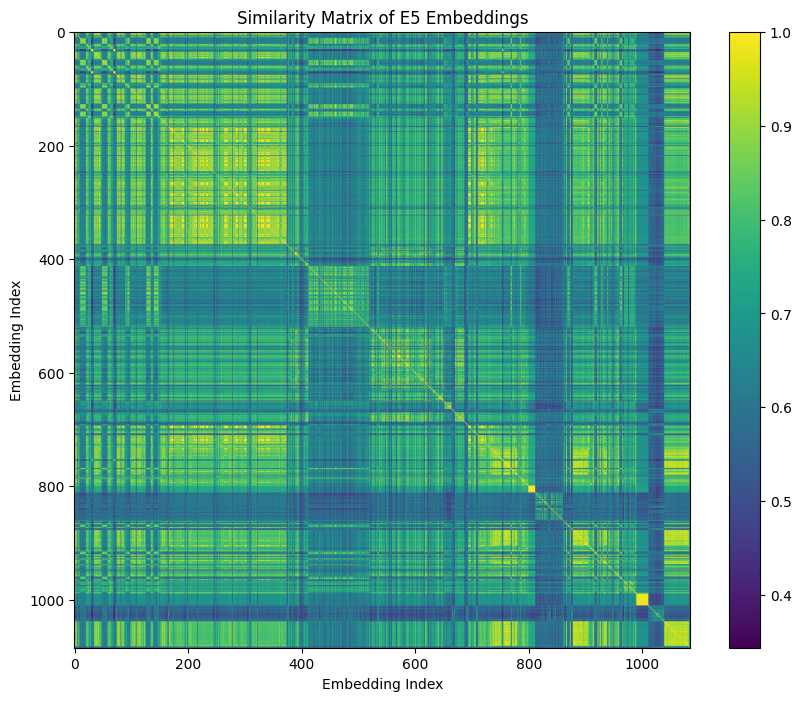

In [52]:
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix_e5_model, cmap='viridis')
plt.colorbar()
plt.title('Similarity Matrix of E5 Embeddings')
plt.xlabel('Embedding Index')
plt.ylabel('Embedding Index')
plt.savefig('similarity_matrix_e5.png')
plt.show()

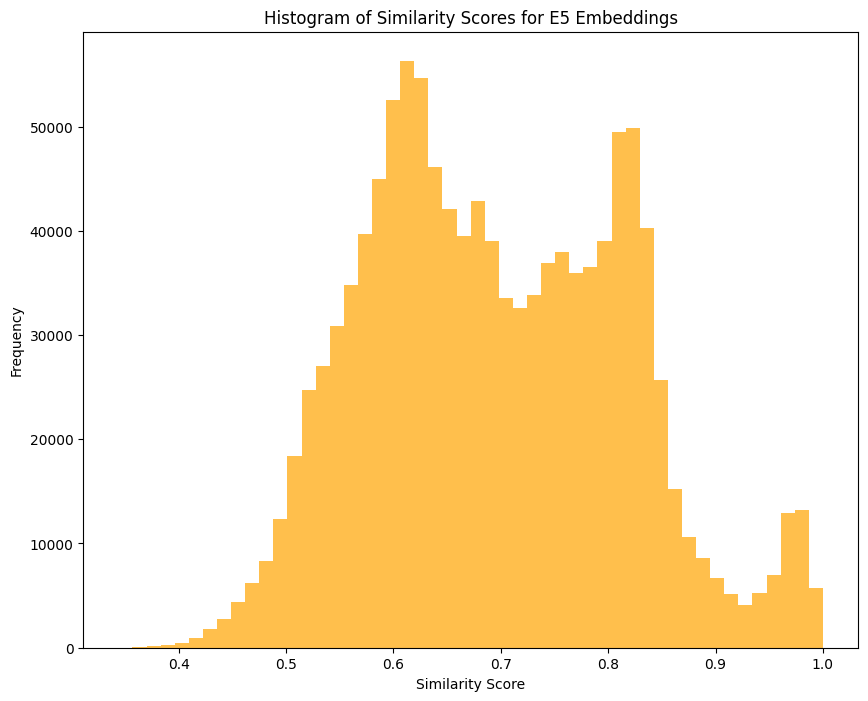

In [53]:
plt.figure(figsize=(10, 8))
plt.hist(similarity_matrix_e5_model.flatten(), bins=50, color='orange', alpha=0.7)
plt.title('Histogram of Similarity Scores for E5 Embeddings')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.savefig('similarity_histogram_e5.png')
plt.show()

## Difference between the two?

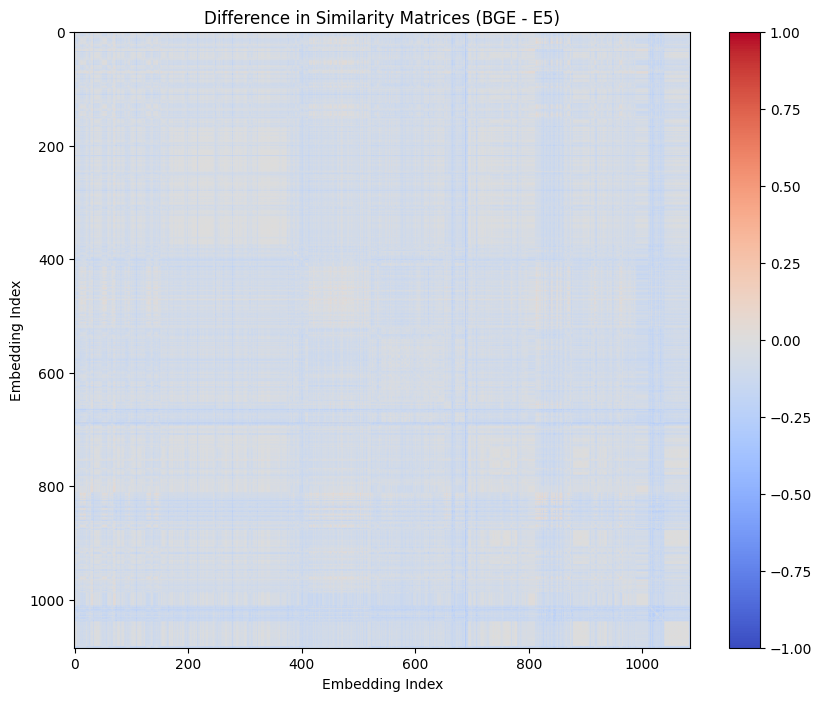

In [54]:
difference = similarity_matrix_bge_model - similarity_matrix_e5_model
plt.figure(figsize=(10, 8))
plt.imshow(difference, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Difference in Similarity Matrices (BGE - E5)')
plt.xlabel('Embedding Index')
plt.ylabel('Embedding Index')
plt.savefig('similarity_matrix_difference.png')
plt.show()

In [55]:
# get num of non0 entries in difference matrix
num_nonzero = np.count_nonzero(difference)
print(f"Number of non-zero entries in difference matrix: {num_nonzero} out of {difference.numpy().size} total entries: {num_nonzero/difference.numpy().size:.2%}")

Number of non-zero entries in difference matrix: 1177154 out of 1177225 total entries: 99.99%


In [56]:
# difference > 0.5
num_not_similar = np.sum(difference.numpy() > 0.0001)
print(f"Number of pairs with difference > 0.01: {num_not_similar} out of {difference.numpy().size} total pairs: {num_not_similar/difference.numpy().size:.4%}")

Number of pairs with difference > 0.01: 60682 out of 1177225 total pairs: 5.1547%


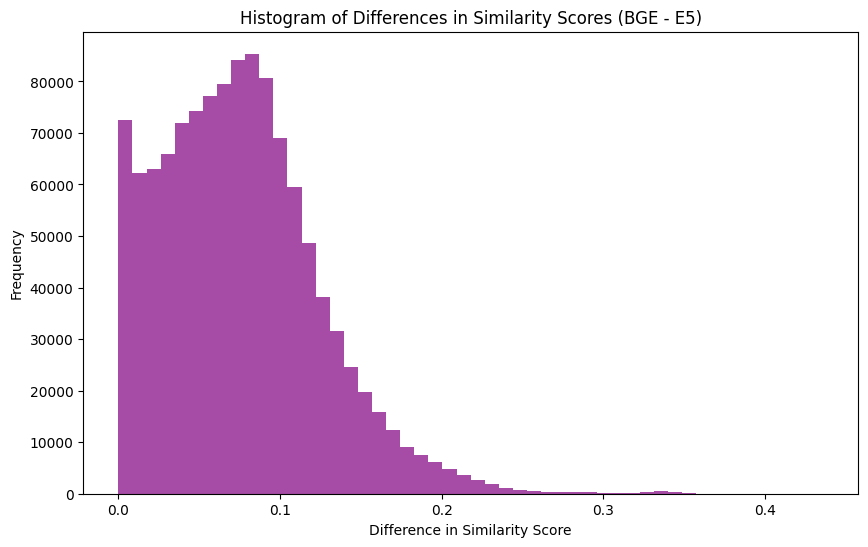

In [57]:
# histogram of differences
plt.figure(figsize=(10, 6))
plt.hist(abs(difference.numpy().flatten()), bins=50, color='purple', alpha=0.7)
plt.title('Histogram of Differences in Similarity Scores (BGE - E5)')
plt.xlabel('Difference in Similarity Score')
plt.ylabel('Frequency')
plt.savefig('similarity_difference_histogram.png')
plt.show()

In [58]:
# get num of pairs with similarity > 0.8 in BGE and E5
num_similar_bge = np.sum(similarity_matrix_bge_model.numpy() > 0.8)
num_similar_e5 = np.sum(similarity_matrix_e5_model.numpy() > 0.8)
print(f"Number of pairs with similarity > 0.8 in BGE: {num_similar_bge} out of {similarity_matrix_bge_model.numpy().size} total pairs: {num_similar_bge/similarity_matrix_bge_model.numpy().size:.2%}")
print(f"Number of pairs with similarity > 0.8 in E5: {num_similar_e5} out of {similarity_matrix_e5_model.numpy().size} total pairs: {num_similar_e5/similarity_matrix_e5_model.numpy().size:.2%}")

Number of pairs with similarity > 0.8 in BGE: 148773 out of 1177225 total pairs: 12.64%
Number of pairs with similarity > 0.8 in E5: 270141 out of 1177225 total pairs: 22.95%
